# Pillar 3 — Big data explorer
Reads the Spark Parquet tables (via DuckDB) and the Kafka summary. Run the Spark and Kafka steps first.

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "datasets")):
    ROOT = os.path.dirname(ROOT)
os.chdir(ROOT)
R = "outputs/results/mohammed_faisal"
import pandas as pd
pd.set_option("display.width", 200, "display.max_columns", 30)
print("repo root:", ROOT)
import duckdb, json
SP = f"{R}/03_big_data/spark"
q = lambda s: duckdb.sql(s).df()

repo root: C:\Users\mohammed.faisal\OneDrive - Presight AI\Desktop\stackup-engineering-academy_assessment


In [2]:
for t in ["project_activity_summary","user_activity_summary","escalation_log","daily_event_volume","peak_usage_analysis"]:
    print(t, q(f"SELECT COUNT(*) n FROM read_parquet('{SP}/{t}/**/*.parquet', hive_partitioning=true)").iloc[0,0])

project_activity_summary 500
user_activity_summary 960
escalation_log 1969


daily_event_volume 5077
peak_usage_analysis 20


In [3]:
q(f"SELECT * FROM read_parquet('{SP}/project_activity_summary/*.parquet') ORDER BY total_events DESC LIMIT 10")

,project_id,total_events,escalation_count,task_completions,document_uploads,last_event_timestamp,unique_users,unique_event_types
0,PRJ0296,146,4,24,17,2025-12-25 13:56:18,138,13
1,PRJ0372,145,2,28,17,2025-12-30 05:57:06,129,11
2,PRJ0381,144,6,26,13,2025-12-29 13:08:40,128,12
3,PRJ0285,144,2,23,19,2025-12-31 02:13:23,131,12
4,PRJ0390,141,4,22,20,2025-12-30 13:38:13,128,12
5,PRJ0266,136,5,22,14,2025-12-27 20:49:34,131,13
6,PRJ0128,136,5,31,20,2025-12-29 23:40:10,122,11
7,PRJ0175,134,7,34,10,2025-12-31 18:41:57,124,13
8,PRJ0029,133,5,23,14,2025-12-30 00:45:43,123,12
9,PRJ0052,133,8,20,7,2025-12-29 18:37:17,127,12


In [4]:
q(f"SELECT severity, COUNT(*) raised, SUM(resolved::INT) resolved, ROUND(AVG(resolution_time_hours),1) avg_hours FROM read_parquet('{SP}/escalation_log/**/*.parquet', hive_partitioning=true) GROUP BY 1 ORDER BY 1")

,severity,raised,resolved,avg_hours
0,Critical,192,88.0,893.3
1,High,596,252.0,1020.0
2,Low,423,205.0,981.0
3,Medium,758,322.0,959.6


In [5]:
q(f"SELECT * FROM read_parquet('{SP}/peak_usage_analysis/*.parquet') LIMIT 10")

,event_date,event_hour,total_events,unique_users,event_types_per_hour
0,2025-07-11,9,25,24,10
1,2025-09-15,21,25,24,9
2,2025-07-19,16,24,24,8
3,2025-08-02,10,24,23,9
4,2025-02-01,3,23,23,8
5,2025-02-02,6,23,22,9
6,2025-02-07,22,23,23,6
7,2025-02-24,19,23,23,10
8,2025-05-21,7,23,22,12
9,2025-10-16,22,23,23,9


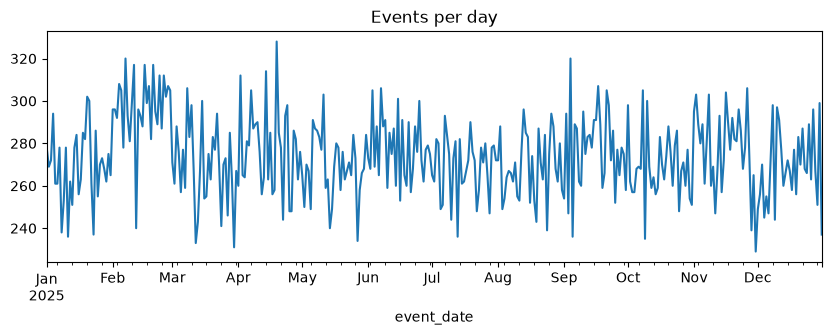

In [6]:
df = q(f"SELECT event_date, SUM(event_count) n FROM read_parquet('{SP}/daily_event_volume/**/*.parquet', hive_partitioning=true) GROUP BY 1 ORDER BY 1")
df.set_index("event_date")["n"].plot(figsize=(10,3), title="Events per day");

## Kafka summary

{'run_at': '2026-09-21T09:27:00.675572+00:00', 'topic': 'presight.project.events', 'total_messages_consumed': 8333, 'critical_escalations_forwarded': 14, 'forwarded_to_topic': 'presight.escalations.critical', 'throughput_messages_per_second': 1969.14, 'elapsed_seconds': 4.23}


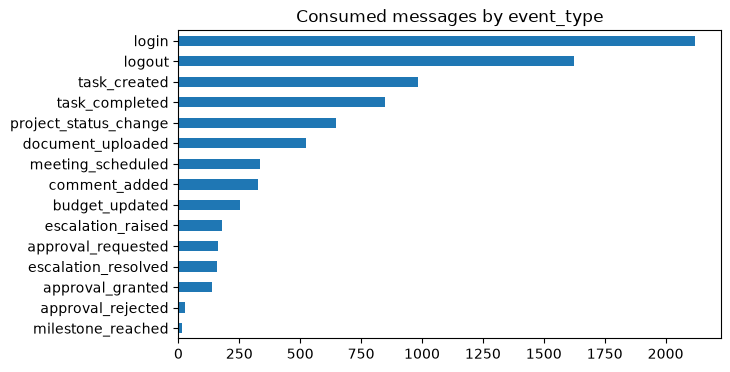

In [7]:
k = json.load(open(f"{R}/03_big_data/kafka/summary.json"))
print({x: k[x] for x in k if x != "event_counts"})
pd.Series(k["event_counts"]).sort_values().plot.barh(figsize=(7,4), title="Consumed messages by event_type");